# Oral listening demo — OpenWind with three parameter sets

This notebook uses **OpenWind for all three listening signals** in order to isolate the effect of the reed parameters from the OpenWind/DG model discrepancy.

For signal 287, we compare:

\[
p_{\rm OW}(L,t;\theta_{\rm init}),
\qquad
p_{\rm OW}(L,t;\theta_{\rm estimated}),
\qquad
p_{\rm OW}(L,t;\theta_{\rm true}),
\]

with

\[
\theta=(\gamma,\kappa,\zeta),
\]

while \(Q_r\) is kept fixed at its known value.

The calibration itself was performed with the differentiable DG solver; OpenWind is used here **only for the listening illustration**.


In [1]:
from pathlib import Path
import copy
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Project root
# ------------------------------------------------------------------
PROJECT_ROOT = Path(
    "/home/rodolphe-vivant/Master/M2/Projet/"
    "2025-m2-projet_automated-calibration-for-musical-instruments"
)

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils.res_openwind import run_openwind_reference

print("Project root:", PROJECT_ROOT)


Project root: /home/rodolphe-vivant/Master/M2/Projet/2025-m2-projet_automated-calibration-for-musical-instruments


## 1. Select the representative calibration case

The numerical values are read directly from `all_signals.csv`.


In [2]:
RESULT_DIR = (
    PROJECT_ROOT
    / "experiments/gradient/results/gamma_kappa_zeta_Qr_fixed_pressure_only"
)

CSV_PATH = RESULT_DIR / "all_signals.csv"
PARAM_JSON = PROJECT_ROOT / "experiments/gradient/config/param.json"

SIGNAL_IDX = 287

OUTPUT_DIR = RESULT_DIR / "oral_audio" / f"signal_{SIGNAL_IDX:03d}_openwind"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)

selected = df.loc[
    (df["signal_idx"] == SIGNAL_IDX) &
    (df["repeat_idx"] == 0)
]

if len(selected) == 0:
    raise RuntimeError(f"signal_idx={SIGNAL_IDX} not found in {CSV_PATH}")

row = selected.iloc[0]

theta_true = np.array([
    row["true_gamma"],
    row["true_kappa"],
    row["true_zeta"],
], dtype=float)

theta_init = np.array([
    0.30,
    0.50,
    0.30,
], dtype=float)

theta_estimated = np.array([
    row["estimated_gamma"],
    row["estimated_kappa"],
    row["estimated_zeta"],
], dtype=float)

Qr_known = float(row["known_Qr"])

print("theta_init      =", theta_init)
print("theta_estimated =", theta_estimated)
print("theta_true      =", theta_true)
print("Qr_known        =", Qr_known)

print()
print("Final parameter errors:")
print(f"gamma : {100.0 * row['relerr_gamma']:.6f} %")
print(f"kappa : {100.0 * row['relerr_kappa']:.6f} %")
print(f"zeta  : {100.0 * row['relerr_zeta']:.6f} %")


theta_init      = [0.3 0.5 0.3]
theta_estimated = [0.52115153 0.88228345 0.48013607]
theta_true      = [0.5211258  0.8822338  0.48007819]
Qr_known        = 153.80069060075772

Final parameter errors:
gamma : 0.004937 %
kappa : 0.005627 %
zeta  : 0.012056 %


## 2. Build the three OpenWind parameter dictionaries

Only \(\gamma\), \(\kappa\), \(\zeta\) change between the three runs.  
The same known \(Q_r\), geometry and remaining physical parameters are used throughout.


In [3]:
with open(PARAM_JSON, "r") as f:
    base_params = json.load(f)

TYPE_S = "const"  # keep the same geometry type as in the calibration dataset

PARAM_PATHS = {
    "gamma": ("left_bc_params", "mouth_pressure_params", "gamma_final"),
    "kappa": ("left_bc_params", "kappa"),
    "zeta": ("left_bc_params", "zeta"),
    "Qr": ("left_bc_params", "Qr"),
}

def set_nested(mapping, path, value):
    current = mapping
    for key in path[:-1]:
        current = current[key]
    current[path[-1]] = float(value)

def make_openwind_params(theta, qr):
    gamma, kappa, zeta = theta

    p = copy.deepcopy(base_params)

    set_nested(p, PARAM_PATHS["gamma"], gamma)
    set_nested(p, PARAM_PATHS["kappa"], kappa)
    set_nested(p, PARAM_PATHS["zeta"], zeta)
    set_nested(p, PARAM_PATHS["Qr"], qr)

    return p

params_init = make_openwind_params(theta_init, Qr_known)
params_estimated = make_openwind_params(theta_estimated, Qr_known)
params_true = make_openwind_params(theta_true, Qr_known)

print("Three OpenWind configurations prepared.")


Three OpenWind configurations prepared.


## 3. Run OpenWind for the three parameter sets

For the oral demo, the simulations are run for **2 seconds**, so the sound does not need to be artificially repeated.

If 2 s is too expensive on your machine, reduce `T_AUDIO` to 1 s.


In [4]:
T_AUDIO = 2.0

# Same OpenWind numerical settings used in the comparison/calibration workflow
OW_THETA = 0.25
OW_L_ELE = 5.0e-4
OW_ORDER = 2

def run_openwind(params):
    (
        t_ow,
        p_left_ow,
        p_right_ow,
        y_ow,
        gamma_ow,
        ow_params,
    ) = run_openwind_reference(
        param_json=params,
        T_max=T_AUDIO,
        type_S=TYPE_S,
        theta=OW_THETA,
        l_ele=OW_L_ELE,
        order=OW_ORDER,
    )

    return (
        np.asarray(t_ow, dtype=float).ravel(),
        np.asarray(p_right_ow, dtype=float).ravel(),
        ow_params,
    )

print("Running initial OpenWind model...")
t_init, p_init, info_init = run_openwind(params_init)

print("Running estimated OpenWind model...")
t_est, p_est, info_est = run_openwind(params_estimated)

print("Running true OpenWind model...")
t_true, p_true, info_true = run_openwind(params_true)

print()
print("Durations:")
print("initial   :", t_init[-1], "s")
print("estimated :", t_est[-1], "s")
print("true      :", t_true[-1], "s")


Running initial OpenWind model...
Géométrie OpenWind native = True
Nombre de segments géométriques = 1
Using Theta scheme, theta = 0.25
TemporalSolver:
Instrument Physics:
Netlist:
	Pipes = ['bore0'];
	Connectors = ['entrance_reed1dof_scaled_source', 'bell_radiation'];
	Fingering Chart = []
--------------------
Player:
	excitator type: Reed1dof_scaled
	control parameters:
		gamma: <function constant_with_initial_ramp.<locals>.pm at 0x7f42196d18a0>
		zeta: 0.3
		kappa: 0.5
		pulsation: 1068.1415022205297
		qfactor: 153.80069060075772
		model: inwards
		contact_stifness: 0
		contact_exponent: 4
		opening: 0.0005
		closing_pressure: 5000.0
Score:
	Note Events: []
	Transition Duration: 0.02
--------------------
Temperature: 20°C
Theta scheme parameter: 0.25
Time step: 5.3406471127825e-07
Mesh info:
	pipes type: [TPipebore0]
	1 pipes of length: [0.5]
	1000 elements distributed as: [1000]
	Orders on each element: [[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

## 4. Put the three OpenWind outputs on one common time grid

The three OpenWind runs may have slightly different internal time grids.  
For plotting and audio export, they are interpolated onto a common uniform grid.


In [5]:
FS_AUDIO = 44100

T_COMMON = min(
    float(t_init[-1]),
    float(t_est[-1]),
    float(t_true[-1]),
    T_AUDIO,
)

t_common = np.arange(
    0.0,
    T_COMMON,
    1.0 / FS_AUDIO,
)

p_init_common = np.interp(t_common, t_init, p_init)
p_est_common = np.interp(t_common, t_est, p_est)
p_true_common = np.interp(t_common, t_true, p_true)

print("Common duration:", T_COMMON, "s")
print("Audio samples  :", len(t_common))


Common duration: 1.9999997329188435 s
Audio samples  : 88200


## 5. Visual comparison

The first 100 ms are shown to make the transient and the onset of oscillation visible.


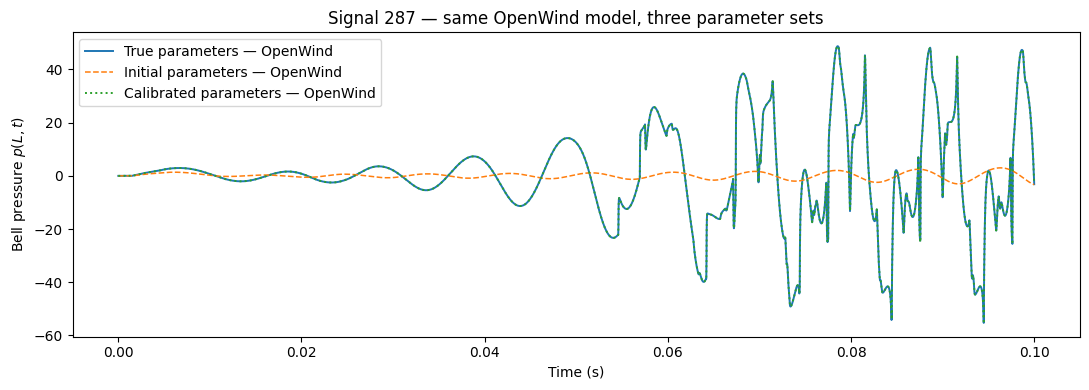

In [6]:
T_PLOT = min(0.10, T_COMMON)
mask = t_common <= T_PLOT

plt.figure(figsize=(11, 4))

plt.plot(
    t_common[mask],
    p_true_common[mask],
    label="True parameters — OpenWind",
    linewidth=1.4,
)

plt.plot(
    t_common[mask],
    p_init_common[mask],
    "--",
    label="Initial parameters — OpenWind",
    linewidth=1.1,
)

plt.plot(
    t_common[mask],
    p_est_common[mask],
    ":",
    label="Calibrated parameters — OpenWind",
    linewidth=1.4,
)

plt.xlabel("Time (s)")
plt.ylabel(r"Bell pressure $p(L,t)$")
plt.title("Signal 287 — same OpenWind model, three parameter sets")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Quantify the effect of calibration

Since all three signals are now generated by the same OpenWind model, the comparison isolates the effect of the parameters.


In [7]:
def rel_l2(pred, ref):
    return np.linalg.norm(pred - ref) / (np.linalg.norm(ref) + 1e-15)

print("Relative L2 error with respect to true-parameter OpenWind:")
print(f"Initial parameters    : {rel_l2(p_init_common, p_true_common):.6e}")
print(f"Calibrated parameters : {rel_l2(p_est_common, p_true_common):.6e}")


Relative L2 error with respect to true-parameter OpenWind:
Initial parameters    : 1.213787e+00
Calibrated parameters : 5.880835e-02


## 7. Save the numerical signals


In [8]:
npz_path = OUTPUT_DIR / "signal_287_openwind_three_parameter_sets.npz"

np.savez(
    npz_path,
    time=t_common,
    openwind_initial=p_init_common,
    openwind_estimated=p_est_common,
    openwind_true=p_true_common,
    theta_init=theta_init,
    theta_estimated=theta_estimated,
    theta_true=theta_true,
    Qr_known=Qr_known,
)

print("Saved:", npz_path)


Saved: /home/rodolphe-vivant/Master/M2/Projet/2025-m2-projet_automated-calibration-for-musical-instruments/experiments/gradient/results/gamma_kappa_zeta_Qr_fixed_pressure_only/oral_audio/signal_287_openwind/signal_287_openwind_three_parameter_sets.npz


## 8. Export the three listening signals as WAV

A **single common gain** is applied to all three files.  
This preserves the relative amplitude differences between the parameter sets.


In [9]:
from scipy.io.wavfile import write as wavwrite

# Remove any tiny DC offset before listening
def remove_dc(x):
    return x - np.mean(x)

audio_init = remove_dc(p_init_common)
audio_est = remove_dc(p_est_common)
audio_true = remove_dc(p_true_common)

common_peak = max(
    np.max(np.abs(audio_init)),
    np.max(np.abs(audio_est)),
    np.max(np.abs(audio_true)),
    1e-12,
)

gain = 0.95 / common_peak

audio_files = {
    "01_initial_parameters_openwind.wav": audio_init,
    "02_calibrated_parameters_openwind.wav": audio_est,
    "03_true_parameters_openwind.wav": audio_true,
}

for filename, signal in audio_files.items():
    out = np.clip(gain * signal, -1.0, 1.0)
    path = OUTPUT_DIR / filename

    wavwrite(
        path,
        FS_AUDIO,
        (32767 * out).astype(np.int16),
    )

    print("Saved:", path)


Saved: /home/rodolphe-vivant/Master/M2/Projet/2025-m2-projet_automated-calibration-for-musical-instruments/experiments/gradient/results/gamma_kappa_zeta_Qr_fixed_pressure_only/oral_audio/signal_287_openwind/01_initial_parameters_openwind.wav
Saved: /home/rodolphe-vivant/Master/M2/Projet/2025-m2-projet_automated-calibration-for-musical-instruments/experiments/gradient/results/gamma_kappa_zeta_Qr_fixed_pressure_only/oral_audio/signal_287_openwind/02_calibrated_parameters_openwind.wav
Saved: /home/rodolphe-vivant/Master/M2/Projet/2025-m2-projet_automated-calibration-for-musical-instruments/experiments/gradient/results/gamma_kappa_zeta_Qr_fixed_pressure_only/oral_audio/signal_287_openwind/03_true_parameters_openwind.wav


## 9. Optional MP3 conversion for the Beamer PDF

From the output directory:

```bash
ffmpeg -i 01_initial_parameters_openwind.wav -b:a 128k 01_initial_parameters_openwind.mp3
ffmpeg -i 02_calibrated_parameters_openwind.wav -b:a 128k 02_calibrated_parameters_openwind.mp3
ffmpeg -i 03_true_parameters_openwind.wav -b:a 128k 03_true_parameters_openwind.mp3
```

For the oral slide, a clear order is:

**Initial parameters** \(\rightarrow\) **Calibrated parameters** \(\rightarrow\) **True parameters**.

A short oral sentence could be:

> “For this listening illustration, I use OpenWind for all three sounds so that only the effect of the parameter values is compared.”
